# Görev 2: Gizli Formülü Bul (Training Loop)

Elimde X ve Y diye iki sütun sayı var. Y'yi üretirken kullandığım formül aslında
`Y = 3 * X + 2` (üstüne biraz da gürültü ekliyorum). Model bu formülü bilmiyor,
sadece sayıları görüyor. Amacım modelin 3 ve 2 sayılarını kendi kendine bulmasını
sağlamak.

Bunu bir eğitim döngüsüyle (training loop) yapıyorum. Döngünün her turunda şu dört
şey oluyor:

1. **Forward pass** - model eldeki parametrelerle bir tahmin üretiyor
2. **Loss** - tahmin gerçek değerden ne kadar sapmış, ölçüyorum
3. **Backward pass** - `loss.backward()` ile "her parametreyi hangi yöne oynatsam
   hata azalır" sorusunun cevabı (gradyan) hesaplanıyor
4. **Update** - `optimizer.step()` ile parametreler o yöne doğru küçük bir adım atıyor

Bu dördünü 1000 kez tekrarlayınca ağırlık 3'e, sapma 2'ye yaklaşmalı. Aşağıda
adım adım yaptım.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# her çalıştırdığımda aynı sayılar gelsin diye seed veriyorum
torch.manual_seed(42)

print(torch.__version__)

2.13.0+cu130


## 1. Adım - Veriyi üretiyorum

Dışarıdan bir dosya indirmiyorum, veriyi kendim uyduruyorum. Bunun güzel tarafı
doğru cevabı baştan biliyor olmam: 3 ve 2. Model eğitim sonunda bu iki sayıya
yaklaşıyorsa öğrenme gerçekten çalışmış demektir.

- `X = torch.randn(100, 1)` -> 100 tane rastgele girdi
- `Y = 3 * X + 2 + gürültü` -> her girdinin gerçek karşılığı

Şekil neden `(100, 1)`? PyTorch katmanları veriyi `(örnek_sayısı, özellik_sayısı)`
şeklinde bekliyor. Burada 100 örneğim var ve her örneğin 1 özelliği (tek bir sayı).
Düz `(100,)` verirsem katman bunu 100 özellikli tek örnek sanar, o yüzden ikinci
ekseni açık bırakıyorum.

Gürültüyü (`* 0.1`) neden ekliyorum? Gerçek hayatta ölçümler hiçbir zaman tam
formüle oturmaz, hep biraz sapma olur. Gürültü olmasaydı problem fazla kolay
olurdu ve loss tam sıfıra inerdi. Gürültü yüzünden loss belli bir noktanın altına
inemeyecek, bu normal.

In [2]:
X = torch.randn(100, 1)

# gizli formül: 3 * X + 2  (model bunu bilmiyor)
Y = 3 * X + 2 + torch.randn(100, 1) * 0.1

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print()
print("ilk 5 örnek (X -> Y):")
for i in range(5):
    print(f"  {X[i].item():7.3f} -> {Y[i].item():7.3f}")

X shape: torch.Size([100, 1])
Y shape: torch.Size([100, 1])

ilk 5 örnek (X -> Y):
    1.927 ->   7.853
    1.487 ->   6.471
    0.901 ->   4.663
   -2.106 ->  -4.264
    0.678 ->   4.138


Veriye bir bakayım, gerçekten doğrusal mı duruyor:

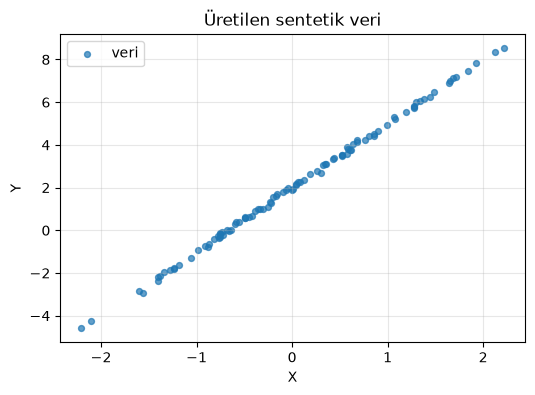

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(X, Y, s=18, alpha=0.7, label="veri")
plt.title("Üretilen sentetik veri")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Noktalar bir doğrunun etrafına dağılmış. Modelin işi tam da o doğruyu bulmak.

## 2. Adım - Modeli tanımlıyorum

`nn.Linear(1, 1)` içeride tek satırlık bir formül tutuyor:

```
y = weight * x + bias
```

`(1, 1)` demek "1 sayı girer, 1 sayı çıkar". İçindeki `weight` ve `bias`
rastgele değerlerle başlıyor, yani model şu an tamamen saçmalıyor. Eğitim bu iki
sayıyı yavaş yavaş 3 ve 2'ye taşıma işi.

Bu iki sayı `requires_grad=True` ile oluşturuluyor. Yani PyTorch bunların üzerinde
yapılan her işlemi kaydediyor ki sonradan gradyanlarını hesaplayabilsin.

In [4]:
model = nn.Linear(1, 1)

print("eğitimden ÖNCEKİ parametreler")
print("  weight :", model.weight.item())
print("  bias   :", model.bias.item())
print()

# modelin öğrenilebilir parametreleri bunlar
for name, p in model.named_parameters():
    print(f"{name:8} shape={tuple(p.shape)}  requires_grad={p.requires_grad}")

eğitimden ÖNCEKİ parametreler
  weight : 0.48010575771331787
  bias   : 0.8415044546127319

weight   shape=(1, 1)  requires_grad=True
bias     shape=(1,)  requires_grad=True


## 3. Adım - Kayıp fonksiyonu ve optimizer

**`nn.MSELoss()` (Mean Squared Error):** tahmin ile gerçek değer arasındaki farkın
karesinin ortalaması. Kare almasının iki sebebi var: eksi farklar artı farkları
götürmesin diye, bir de büyük hatalar daha çok cezalansın diye. Tek bir sayı
üretiyor ve amacım o sayıyı küçültmek.

**`torch.optim.SGD`:** gradyanlara bakıp parametreleri güncelleyen kısım. Yaptığı
iş özünde şu:

```
yeni_parametre = eski_parametre - lr * gradyan
```

Gradyan "hatayı artıran yön" olduğu için eksisine gidiyoruz. `lr` (learning rate)
o yönde ne kadar büyük adım atacağımızı belirliyor. Çok küçük olursa öğrenme
sürünüyor, çok büyük olursa hedefin üstünden atlayıp savruluyor. 0.01 ile
başlıyorum, sonunda farklı değerleri deneyip farkı gösterdim.

`model.parameters()` derken optimizer'a "senin oynayacağın sayılar bunlar" demiş
oluyorum.

In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(criterion)
print(optimizer)

MSELoss()
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## Eğitimden önceki tahminleri saklıyorum

Sonunda "önce / sonra" grafiği çizebilmek için modelin şu anki (henüz cahil)
tahminlerini kenara koyuyorum.

Burada `torch.no_grad()` kullanıyorum. Normalde PyTorch her işlemi bir hesap
grafiğinde kaydediyor ki `backward()` çağrıldığında geriye doğru türev
alabilsin. Ama ben burada öğrenmiyorum, sadece bakıyorum. `no_grad()` bloğu
içinde bu kayıt tutma kapanıyor; hem gereksiz bellek harcanmıyor hem de bu
işlem yanlışlıkla gradyanlara karışmıyor.

In [6]:
with torch.no_grad():
    y_pred_before = model(X)

print("eğitim öncesi ilk 5 tahmin (tahmin / gerçek):")
for i in range(5):
    print(f"  {y_pred_before[i].item():7.3f} / {Y[i].item():7.3f}")

with torch.no_grad():
    print()
    print("başlangıç loss:", criterion(model(X), Y).item())

eğitim öncesi ilk 5 tahmin (tahmin / gerçek):
    1.767 /   7.853
    1.556 /   6.471
    1.274 /   4.663
   -0.169 /  -4.264
    1.167 /   4.138

başlangıç loss: 7.852996826171875


## 4. Adım - Eğitim döngüsü

Asıl kısım burası. 1000 tur boyunca aynı dört adımı tekrarlıyorum:

**1) `optimizer.zero_grad()` - gradyanları sıfırla**
PyTorch gradyanları üzerine yazmaz, **toplar**. Yani bu satırı yazmazsam bu turun
gradyanı önceki turların gradyanının üstüne eklenir ve adımlar giderek saçmalar.
Aşağıda bunu deneyerek gösterdim. Döngünün başında temiz sayfa açıyorum.

**2) `y_pred = model(X)` - forward pass**
Model eldeki weight ve bias ile tahminini üretiyor. Aynı anda PyTorch arka planda
"bu sonuç hangi işlemlerden geçerek oluştu" grafiğini kuruyor.

**3) `loss = criterion(y_pred, Y)` - hatayı ölç**
Tahminler gerçekten ne kadar uzak, tek sayıya indirgiyorum.

**4) `loss.backward()` - backward pass**
Grafiği tersten yürüyüp zincir kuralıyla her parametrenin türevini hesaplıyor ve
`param.grad` içine yazıyor. Yani "weight'i 1 birim artırsam loss ne kadar
değişir" sorusunun cevabı.

**5) `optimizer.step()` - güncelle**
Hesaplanan gradyanlara bakıp parametreleri hatayı azaltacak yönde biraz oynatıyor.

Sıra önemli: önce temizle, sonra tahmin et, hatayı ölç, türevi al, en son adım at.
`step()`'i `backward()`'dan önce çağırırsam elimde o turun gradyanı olmadığı için
model yanlış yöne gider.

In [7]:
epochs = 1000
loss_history = []

for epoch in range(epochs):
    # 1) önceki turdan kalan gradyanları temizle
    optimizer.zero_grad()

    # 2) forward pass - model tahminini üretiyor
    y_pred = model(X)

    # 3) hatayı ölç
    loss = criterion(y_pred, Y)

    # 4) backward pass - her parametrenin gradyanı hesaplanıyor
    loss.backward()

    # 5) parametreleri güncelle
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        w = model.weight.item()
        b = model.bias.item()
        print(f"epoch {epoch+1:4d} | loss: {loss.item():.6f} | weight: {w:.4f} | bias: {b:.4f}")

epoch  100 | loss: 0.142915 | weight: 2.6603 | bias: 1.8906
epoch  200 | loss: 0.010157 | weight: 2.9543 | bias: 1.9942


epoch  300 | loss: 0.007847 | weight: 2.9946 | bias: 2.0031


epoch  400 | loss: 0.007804 | weight: 3.0003 | bias: 2.0036
epoch  500 | loss: 0.007804 | weight: 3.0010 | bias: 2.0036


epoch  600 | loss: 0.007804 | weight: 3.0012 | bias: 2.0036


epoch  700 | loss: 0.007804 | weight: 3.0012 | bias: 2.0036


epoch  800 | loss: 0.007804 | weight: 3.0012 | bias: 2.0036
epoch  900 | loss: 0.007804 | weight: 3.0012 | bias: 2.0036


epoch 1000 | loss: 0.007804 | weight: 3.0012 | bias: 2.0036


Çıktıda weight'in 3'e, bias'ın 2'ye doğru sürüklendiği görülüyor. Loss da hızla
düşüp sonra yavaşlıyor; çünkü hedefe yaklaştıkça gradyan küçülüyor, adımlar da
küçülüyor.

## Sonuç - model formülü buldu mu?

In [8]:
final_w = model.weight.item()
final_b = model.bias.item()

print("gerçek formül   : Y = 3.0000 * X + 2.0000")
print(f"öğrenilen formül: Y = {final_w:.4f} * X + {final_b:.4f}")
print()
print(f"weight hatası   : {abs(final_w - 3):.4f}")
print(f"bias hatası     : {abs(final_b - 2):.4f}")
print()
print(f"ilk loss        : {loss_history[0]:.6f}")
print(f"son loss        : {loss_history[-1]:.6f}")

gerçek formül   : Y = 3.0000 * X + 2.0000
öğrenilen formül: Y = 3.0012 * X + 2.0036

weight hatası   : 0.0012
bias hatası     : 0.0036

ilk loss        : 7.852997
son loss        : 0.007804


Değerler 3 ve 2'ye çok yakın. Tam tutmuyor çünkü veriye kasıtlı olarak gürültü
ekledim; model gürültülü noktalara en iyi uyan doğruyu buluyor, gizli formülün
kendisini birebir kopyalamıyor.

## Loss eğrisi

Öğrenmenin nasıl ilerlediğine bakalım:

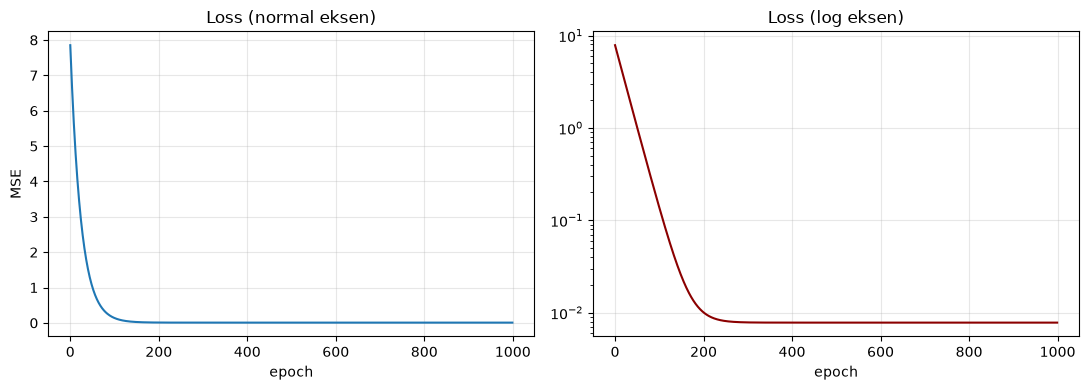

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(loss_history)
ax[0].set_title("Loss (normal eksen)")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("MSE")
ax[0].grid(alpha=0.3)

ax[1].plot(loss_history, color="darkred")
ax[1].set_yscale("log")
ax[1].set_title("Loss (log eksen)")
ax[1].set_xlabel("epoch")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Soldaki grafikte loss başta dik iniyor sonra yatıyor. Log eksende bakınca
düşüşün aslında sonlara doğru da devam ettiği, sadece ölçek yüzünden düz göründüğü
anlaşılıyor. En sonda çizgi düzleşiyor: orası gürültüden gelen, azaltılamayan hata.

## Eğitim öncesi ve sonrası tahminler

Şimdi modelin başta çizdiği doğru ile sonda çizdiği doğruyu yan yana koyuyorum.
Yine `torch.no_grad()` içinde tahmin alıyorum, çünkü sadece grafik çizeceğim;
burada öğrenme yok, gradyan hesabına gerek yok.

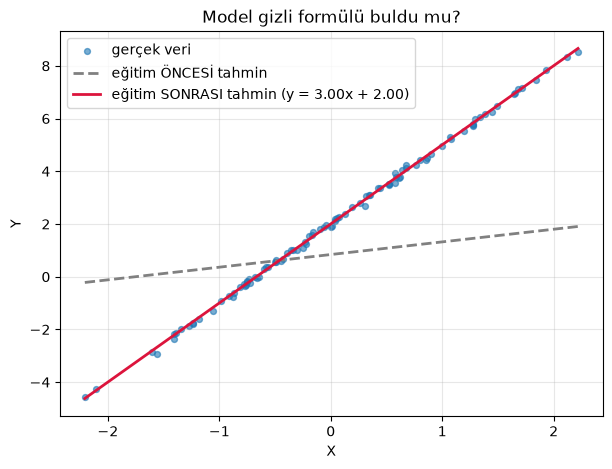

In [10]:
with torch.no_grad():
    y_pred_after = model(X)

# doğruları düzgün çizebilmek için X'i sıraya diziyorum
order = torch.argsort(X.squeeze())
X_sorted = X[order]

plt.figure(figsize=(7, 5))
plt.scatter(X, Y, s=18, alpha=0.6, label="gerçek veri")
plt.plot(X_sorted, y_pred_before[order], "--", color="gray", linewidth=2,
         label="eğitim ÖNCESİ tahmin")
plt.plot(X_sorted, y_pred_after[order], color="crimson", linewidth=2,
         label=f"eğitim SONRASI tahmin (y = {final_w:.2f}x + {final_b:.2f})")
plt.title("Model gizli formülü buldu mu?")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Kesikli gri çizgi rastgele başlangıç, kırmızı çizgi eğitim sonrası. Kırmızı çizgi
noktaların tam ortasından geçiyor.

---

## Deney 1 - `optimizer.zero_grad()` olmasa ne olurdu?

Yukarıda "PyTorch gradyanları toplar" dedim. Bunu lafta bırakmayıp deneyelim.
Sıfırdan iki model kuruyorum, ikisini de aynı ayarlarla eğitiyorum; tek fark
birinde `zero_grad()` var, diğerinde yok.

In [11]:
def egit(zero_grad_kullan, epochs=1000, lr=0.01, seed=0):
    torch.manual_seed(seed)
    m = nn.Linear(1, 1)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    crit = nn.MSELoss()
    gecmis = []

    for _ in range(epochs):
        if zero_grad_kullan:
            opt.zero_grad()
        out = m(X)
        l = crit(out, Y)
        l.backward()
        opt.step()
        gecmis.append(l.item())

    return m, gecmis


m_dogru, g_dogru = egit(zero_grad_kullan=True)
m_hatali, g_hatali = egit(zero_grad_kullan=False)

print("zero_grad VAR  -> weight: {:.4f}  bias: {:.4f}  son loss: {:.6f}".format(
    m_dogru.weight.item(), m_dogru.bias.item(), g_dogru[-1]))
print("zero_grad YOK  -> weight: {:.4f}  bias: {:.4f}  son loss: {:.6f}".format(
    m_hatali.weight.item(), m_hatali.bias.item(), g_hatali[-1]))

zero_grad VAR  -> weight: 3.0012  bias: 2.0036  son loss: 0.007804
zero_grad YOK  -> weight: 2.0720  bias: -0.9045  son loss: 10.459112


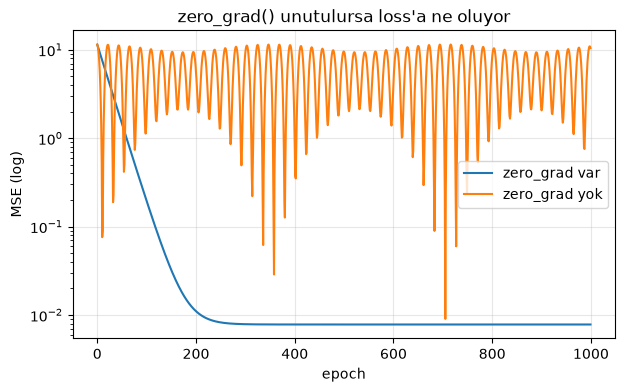

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(g_dogru, label="zero_grad var")
plt.plot(g_hatali, label="zero_grad yok")
plt.yscale("log")
plt.title("zero_grad() unutulursa loss'a ne oluyor")
plt.xlabel("epoch")
plt.ylabel("MSE (log)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

İlginç bir sonuç çıktı: `zero_grad()` olmayan model patlamıyor ama bir türlü
duramıyor. Loss önce güzelce düşüyor, sonra tekrar tepeye tırmanıyor, sonra yine
düşüyor; sürekli salınıyor ve hiçbir zaman oturmuyor.

Sebebi şu: gradyanlar sıfırlanmadığı için `param.grad` o ana kadarki bütün
gradyanların toplamını tutuyor. Yani model artık "şu anki eğime göre" adım atmıyor,
"o ana kadar biriken bütün eğimlerin toplamına göre" adım atıyor. Hedefe vardığında
anlık gradyan sıfırlanıyor ama biriken toplam hâlâ büyük olduğu için model durmayıp
öbür tarafa geçiyor. Sarkaç gibi: doğru noktadan her seferinde geçiyor, ama frenleyen
bir şey olmadığı için hiç durmuyor.

Sonuç olarak `zero_grad()` unutulduğunda model öğreniyormuş gibi görünüp aslında
yakınsamıyor. Bu yüzden döngünün ilk satırı her zaman `optimizer.zero_grad()`.

(PyTorch'un bunu otomatik yapmamasının sebebi de var aslında: bazı durumlarda
gradyanı bilerek biriktiriyoruz, mesela GPU'ya sığmayan büyük batch'leri parçalara
bölüp gradyanlarını toplayarak tek büyük adım atmak istediğimizde.)

## Deney 2 - Learning rate ne kadar önemli?

Aynı modeli farklı `lr` değerleriyle eğitip sonuçlara bakıyorum.

In [13]:
for lr in [0.001, 0.01, 0.1, 1.2]:
    m, g = egit(zero_grad_kullan=True, lr=lr)
    print("lr = {:<6} -> weight: {:>10.4f}  bias: {:>10.4f}  son loss: {:.6f}".format(
        lr, m.weight.item(), m.bias.item(), g[-1]))

lr = 0.001  -> weight:     2.5884  bias:     1.8544  son loss: 0.202940


lr = 0.01   -> weight:     3.0012  bias:     2.0036  son loss: 0.007804


lr = 0.1    -> weight:     3.0012  bias:     2.0036  son loss: 0.007804


lr = 1.2    -> weight:        nan  bias:        nan  son loss: nan


Okuduğum kadarıyla:

- **lr = 0.001** -> adımlar çok küçük, 1000 epoch yetmiyor. Doğru yöne gidiyor ama
  3 ve 2'ye varamadan yolda kalıyor, loss da yüksek kalıyor.
- **lr = 0.01** -> dengeli, 3 ve 2'ye oturuyor.
- **lr = 0.1** -> daha hızlı yakınsıyor, bu problem için sorun çıkarmıyor.
- **lr = 1.2** -> adımlar hedefin üstünden atlıyor, her seferinde daha da
  savruluyor ve değerler patlıyor (`inf` / `nan`). Yani sorun her zaman modelde
  değil, bazen sadece adım boyunda.

---

## Değerlendirme

### Model nasıl öğrendi?

Model formülü "çözerek" bulmadı, **deneme-yanılmayı sistematik hale getirerek**
buldu. Süreç şöyle işledi:

Başlangıçta weight ve bias rastgele iki sayıydı, model saçma tahminler yapıyordu.
Her turda bu tahminlerin gerçek değerlerden ne kadar saptığını MSE ile tek bir
sayıya indirdim. Sonra `loss.backward()` ile "bu sayıyı azaltmak için weight'i ve
bias'ı hangi yöne oynatmalıyım" sorusunun cevabını hesapladım. `optimizer.step()`
de parametreleri o yönde küçük bir adım kaydırdı.

Tek bir adım hiçbir şey ifade etmiyor, ama bunu 1000 kez tekrarlayınca parametreler
hatanın en küçük olduğu noktaya doğru kaydı. O nokta da zaten verinin arkasındaki
gerçek formül, yani 3 ve 2. Model "gizli formülü" bilmediği halde, hatayı azaltmaya
çalışa çalışa aynı yere geldi.

Buradaki asıl fikir şu: öğrenme, hatayı parametrelere göre türevlemek ve türevin
gösterdiği yönün tersine yürümek. Bütün derin öğrenme, milyarlarca parametreyle de
olsa, temelde bu döngüyü çalıştırıyor.

### Eğitim döngüsündeki temel adımlar ne işe yarıyor?

| Adım | Ne yapıyor |
|---|---|
| `optimizer.zero_grad()` | Önceki turdan kalan gradyanları siliyor. PyTorch gradyanları topladığı için bu olmazsa adımlar birikip bozuluyor. |
| `model(X)` (forward) | Modelin o anki parametreleriyle tahmin üretiyor, aynı anda türev alınabilmesi için hesap grafiğini kuruyor. |
| `criterion(y_pred, Y)` | Tahmin ile gerçek arasındaki farkı tek bir sayıya (loss) indiriyor. Optimize edilecek hedef bu. |
| `loss.backward()` | Grafiği tersten yürüyüp zincir kuralıyla her parametrenin gradyanını hesaplıyor ve `param.grad` içine yazıyor. |
| `optimizer.step()` | Gradyanlara bakıp parametreleri hatayı azaltacak yönde güncelliyor. Modelin gerçekten "değiştiği" tek satır bu. |
| `torch.no_grad()` | Sadece tahmin alacağım yerlerde (grafik, değerlendirme) grafik kaydını kapatıyor; bellek harcamıyor ve o işlemler öğrenmeye karışmıyor. |

`backward()` hesaplıyor, `step()` uyguluyor, `zero_grad()` temizliyor. Üçü de
olmadan döngü çalışmıyor.

### Sonuç

`Y = 3X + 2` ile ürettiğim veriyi modele verdim, model 1000 epoch sonunda
parametrelerini 3 ve 2'ye çok yakın değerlere getirdi. Grafikte de eğitim öncesi
rastgele doğrunun eğitim sonunda noktaların tam ortasına oturduğu görülüyor.
Ayrıca `zero_grad()` unutulduğunda ve learning rate yanlış seçildiğinde eğitimin
nasıl bozulduğunu deneyerek gördüm.